# Beam v3 near-completion shrinkage

Use the full banded Cholesky basis and its last `n-m` omitted directions to evaluate the v3 operation: take the coordinate hull first, then intersect it with the initial box. Only the requested shrinkage percentages and histogram are retained.

In [1]:
from pathlib import Path
import gc
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import cholesky_banded, solveh_banded
from scipy.linalg.lapack import get_lapack_funcs
from scipy.sparse import csr_matrix, diags


with Path("wing_bsm_30k.pkl").open("rb") as file:
    K_full, F_full, U_full, B0_1_full, B0_2_full = pickle.load(file)

A_full = csr_matrix(K_full)
A = A_full[3:, 3:].tocsr()
b = np.asarray(F_full[3:], dtype=float).copy()
stored_solution = np.asarray(U_full[3:], dtype=float).copy()
initial_box = np.asarray(B0_1_full[3:], dtype=float).copy()
if not np.array_equal(B0_1_full[3:], B0_2_full[3:]):
    raise ValueError("The two beam boxes differ after removing the BC coordinates.")

del K_full, F_full, U_full, B0_1_full, B0_2_full, A_full
gc.collect()

n = b.size
diagonal = A.diagonal()
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = (diags(inverse_scale) @ A @ diags(inverse_scale)).tocsr()
b_hat = inverse_scale * b

rows, columns = A_hat.nonzero()
bandwidth = int(np.max(rows - columns))
A_banded = np.zeros((bandwidth + 1, n), dtype=float)
for offset in range(bandwidth + 1):
    A_banded[offset, : n - offset] = A_hat.diagonal(-offset)

L_banded = cholesky_banded(A_banded, lower=True, check_finite=False)
y_star = solveh_banded(A_banded, b_hat, lower=True, check_finite=False)
x_star = inverse_scale * y_star

outside_original_box = (x_star < initial_box[:, 0]) | (x_star > initial_box[:, 1])
effective_box = np.column_stack([
    np.minimum(initial_box[:, 0], x_star),
    np.maximum(initial_box[:, 1], x_star),
])
lower0 = scale * effective_box[:, 0]
upper0 = scale * effective_box[:, 1]
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)

print(f"system dimension n: {n:,}")
print(f"scaled bandwidth: {bandwidth}")
print(f"independent Cholesky directions: {np.count_nonzero(L_banded[0] > 0):,}")
print(f"coordinates expanded to contain the solution: {outside_original_box.sum():,}")

system dimension n: 30,000
scaled bandwidth: 4
independent Cholesky directions: 30,000
coordinates expanded to contain the solution: 3,334


In [2]:
omitted_counts = np.arange(0, 1201, 150, dtype=int)
m_values = n - omitted_counts
max_omitted = int(omitted_counts[-1])
tail_start = n - max_omitted

# P = L^{-T}.  Only its final 1,200 columns are needed.
LT_banded = np.zeros_like(L_banded)
for offset in range(bandwidth + 1):
    LT_banded[bandwidth - offset, offset:] = L_banded[offset, : n - offset]

tail_rhs = np.zeros((n, max_omitted), dtype=float, order="F")
tail_rhs[tail_start:, :] = np.eye(max_omitted)
tbtrs = get_lapack_funcs("tbtrs", (LT_banded, tail_rhs))
P_tail, info = tbtrs(
    LT_banded, tail_rhs, uplo="U", trans="N", diag="N", overwrite_b=1
)
if info != 0:
    raise RuntimeError(f"LAPACK triangular band solve failed with info={info}.")


def hull_then_intersect(omitted):
    """Return v3 bounds for m=n-omitted using the complementary tail projector."""
    if omitted == 0:
        return y_star.copy(), y_star.copy()

    start = n - omitted
    P = P_tail[:, max_omitted - omitted :]

    # Pi = P_tail P_tail^T A = P_tail times the matching rows of L^T.
    # Those rows have only `bandwidth + 1` nonzero diagonals.
    Pi = P * L_banded[0, start:][None, :]
    for offset in range(1, bandwidth + 1):
        Pi[:, offset:] += (
            P[:, : omitted - offset]
            * L_banded[offset, start : start + omitted - offset][None, :]
        )

    projected_center = y_star + Pi @ (center0[start:] - y_star[start:])
    projected_radius = np.abs(Pi) @ radius0[start:]
    hull_lower = projected_center - projected_radius
    hull_upper = projected_center + projected_radius
    lower = np.maximum(lower0, hull_lower)
    upper = np.minimum(upper0, hull_upper)
    if np.any(lower > upper):
        raise RuntimeError("Roundoff produced an empty coordinate intersection.")
    return lower, upper


initial_width = upper0 - lower0
shrinkage_pct = np.empty((len(omitted_counts), n), dtype=float)
for row, omitted in enumerate(omitted_counts):
    lower, upper = hull_then_intersect(int(omitted))
    shrinkage_pct[row] = np.clip(
        100.0 * (1.0 - (upper - lower) / initial_width), 0.0, 100.0
    )

if not np.all(shrinkage_pct[0] == 100.0):
    raise AssertionError("The m=n enclosure did not contract to degeneracy.")

quantile_levels = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0])
quantiles = np.quantile(shrinkage_pct, quantile_levels, axis=1).T
print("Shrinkage across all coordinates (%)")
print("m       omitted    mean    median     min     p10     p90     max")
for m, omitted, values, qs in zip(m_values, omitted_counts, shrinkage_pct, quantiles):
    print(
        f"{m:5d}   {omitted:7d}   {values.mean():6.2f}   {np.median(values):6.2f}"
        f"   {qs[0]:6.2f}  {qs[1]:6.2f}  {qs[5]:6.2f}  {qs[6]:6.2f}"
    )

results_dir = Path("system_beam_to_completion_results")
results_dir.mkdir(exist_ok=True)
np.savez_compressed(
    results_dir / "v3_shrinkage_percentages.npz",
    n=n,
    m_values=m_values,
    omitted_counts=omitted_counts,
    shrinkage_pct=shrinkage_pct,
    expanded_coordinate_count=outside_original_box.sum(),
)

Shrinkage across all coordinates (%)
m       omitted    mean    median     min     p10     p90     max
30000         0   100.00   100.00   100.00  100.00  100.00  100.00
29850       150    63.57    77.12     0.00    0.00   98.30  100.00
29700       300    63.37    76.97     0.00    0.00   98.29  100.00
29550       450    63.16    76.82     0.00    0.00   98.27  100.00
29400       600    62.96    76.66     0.00    0.00   98.26  100.00
29250       750    62.75    76.51     0.00    0.00   98.24  100.00
29100       900    62.55    76.35     0.00    0.00   98.23  100.00
28950      1050    62.34    76.19     0.00    0.00   98.21  100.00
28800      1200    62.13    76.02     0.00    0.00   98.20  100.00


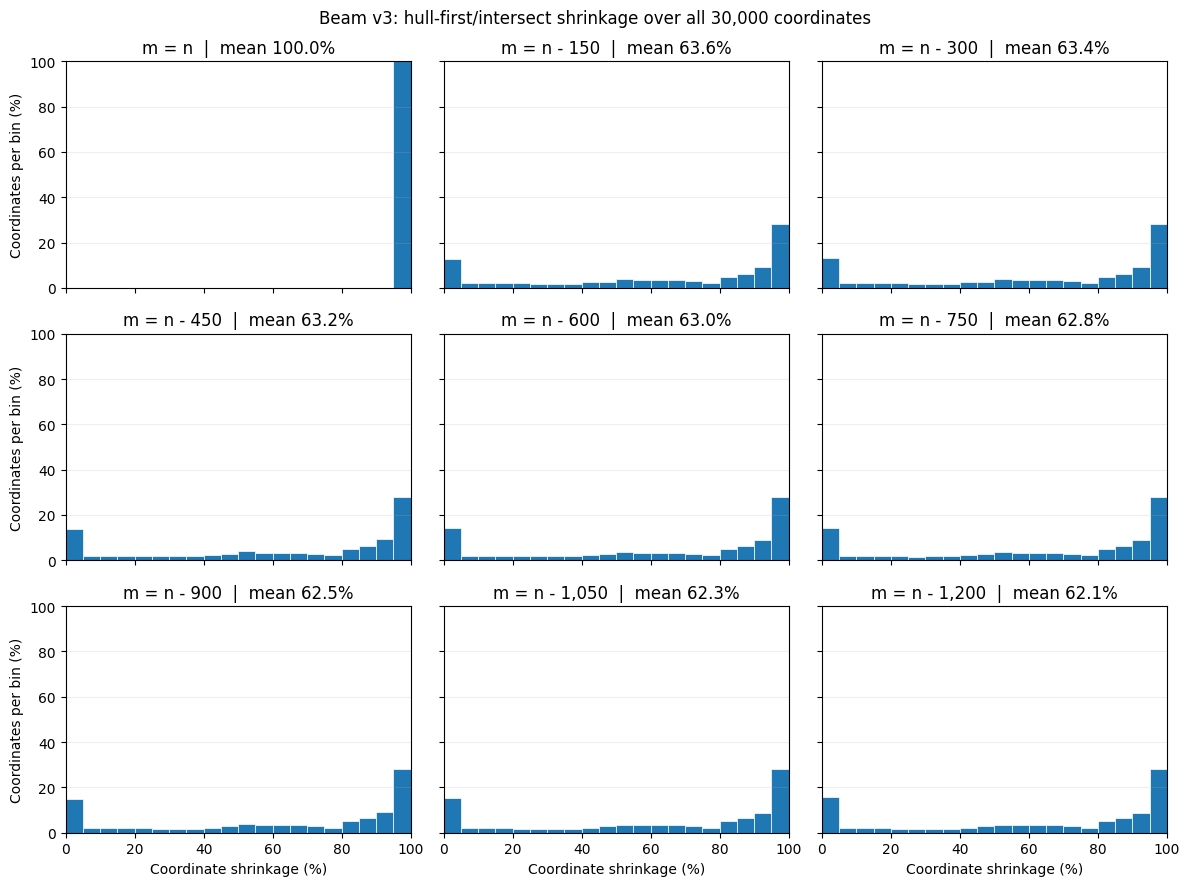

saved system_beam_to_completion_results/v3_shrinkage_histogram.png


In [3]:
bins = np.linspace(0.0, 100.0, 21)
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
for ax, m, omitted, values in zip(axes.ravel(), m_values, omitted_counts, shrinkage_pct):
    ax.hist(
        values, bins=bins, weights=np.full(n, 100.0 / n),
        color="tab:blue", edgecolor="white", linewidth=0.5,
    )
    label = "m = n" if omitted == 0 else f"m = n - {omitted:,}"
    ax.set_title(f"{label}  |  mean {values.mean():.1f}%")
    ax.grid(axis="y", alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel("Coordinate shrinkage (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Coordinates per bin (%)")
for ax in axes.ravel():
    ax.set_xlim(0.0, 100.0)
    ax.set_ylim(0.0, 100.0)

fig.suptitle("Beam v3: hull-first/intersect shrinkage over all 30,000 coordinates")
fig.tight_layout()
figure_path = results_dir / "v3_shrinkage_histogram.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")